In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='bmi', ylabel='charges'>

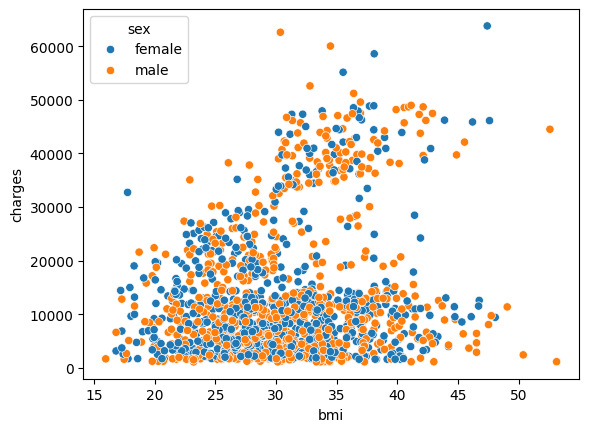

In [11]:
sns.scatterplot(x= df["bmi"], y=df["charges"], hue=df["sex"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [ ]:
X = df.drop(columns=["region", "charges"])
Y = df["charges"]

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [13]:
X.head()

,age,sex,bmi,children,smoker
0,19,female,27.900,0,yes
1,18,male,33.770,1,no
2,28,male,33.000,3,no
3,33,male,22.705,0,no
4,32,male,28.880,0,no


In [14]:
Y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [15]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=11)

In [21]:
X_test.head()

,age,sex,bmi,children,smoker
1313,19,1,34.700,2,1
1254,34,1,27.720,0,0
372,42,1,33.155,1,0
937,39,1,24.225,5,0
484,48,0,34.300,3,0


In [19]:
X["sex"] = X["sex"].map({"female": 1, "male": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_pred = model.predict(X_test)

In [26]:
y_pred

array([28653.45322101,  5716.59199942, 10155.64575323,  8594.95726656,
       12797.67767877, 10857.45009524,  8218.11840467, 15985.45463541,
       12231.477384  , 33250.48144822,  6931.25148327, 15781.06111991,
       10405.02811321,  2650.42477534,  6044.4846084 , 35636.35488403,
        4181.91271341,    41.61720436,  8601.03609218, 13506.14369938,
       10449.80051967,  3019.97111144,  3283.19853664,  4651.9026044 ,
        4669.49619196, 15413.66432859,  5052.06553173,  7978.94166733,
       27134.62841528,  7728.54682247, 32635.52890001, 30196.11087688,
        2674.53330461,  -967.04878225, 31633.23408567, 13878.56302206,
        6084.04797242, 26538.52366059, 11222.40414051,  9101.56559803,
        6388.34554013, 12556.28130001, 27684.1117854 ,   512.54293995,
        9585.12414348, 11631.56553394, 30177.65584912,  3174.97464658,
        8897.5421372 , 26259.56785283, 13611.23872678, 29462.86570565,
       15545.04283608, 35691.28161536, 11473.7562008 ,  3111.55605741,
      

In [27]:
Y_test

1313    36397.576000
1254     4415.158800
372      7639.417450
937      8965.795750
484      9563.029000
            ...     
427      7323.734819
1153     5630.457850
973      1759.338000
608      4435.094200
775     10560.491700
Name: charges, Length: 268, dtype: float64

In [29]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, y_pred)
print("r-squared:", r2)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2) * (n-1) / (n-p-1))
print("adjusted r^2:", adjusted_r2)

r-squared: 0.7988664278143269
adjusted r^2: 0.7950280008642187


In [30]:
X_test.shape

(268, 5)

In [ ]:
print("Hello")